In [5]:
with open('names.txt','r') as f:
    names=[line.strip() for line in f.readlines()]

In [6]:
names

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [7]:
print(len(names))

32033


## creating 2d array

In [8]:
import torch

In [40]:
chars=set(''.join(names)) # set of all characters in names by joinging each names in a string
chars

{'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z'}

In [75]:
stoi = {ch: i + 1 for i, ch in enumerate(sorted(chars))}  # Sort characters before mapping
stoi['.'] = 0  # Add a special character for padding
itos = {i: ch for ch, i in stoi.items()}  # Index to character mapping

In [76]:
print(stoi)
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [77]:
sz=len(stoi) # size of the vocabulary
arr=torch.zeros((sz, sz), dtype=torch.int) # adjacency matrix
# print(arr)

In [78]:
for word in names:
    word = ['.'] + list(word) + ['.']
    for ch1,ch2  in zip(word, word[1:]):
        id1=stoi[ch1] # index of first character
        id2=stoi[ch2] # index of second character
        arr[id1, id2] += 1 # increment the count in the adjacency matrix
        

## visualize

In [79]:
arr

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

"\nWhen you use plt.imshow(arr, cmap='Blues'), the matrix arr is displayed such that:\n\nRows (i) correspond to the vertical axis (y-axis).\nColumns (j) correspond to the horizontal axis (x-axis).\nWhy plt.text(j, i, ...) Aligns with arr[i, j]\nIn the adjacency matrix arr[i, j]:\n\ni is the row index (first character).\nj is the column index (second character).\nWhen placing text on the plot:\n\nplt.text(j, i, ...) specifies the position (j, i) in terms of the plot's x and y coordinates.\nThis matches the matrix cell arr[i, j] because:\nj corresponds to the column (horizontal position).\ni corresponds to the row (vertical position)."

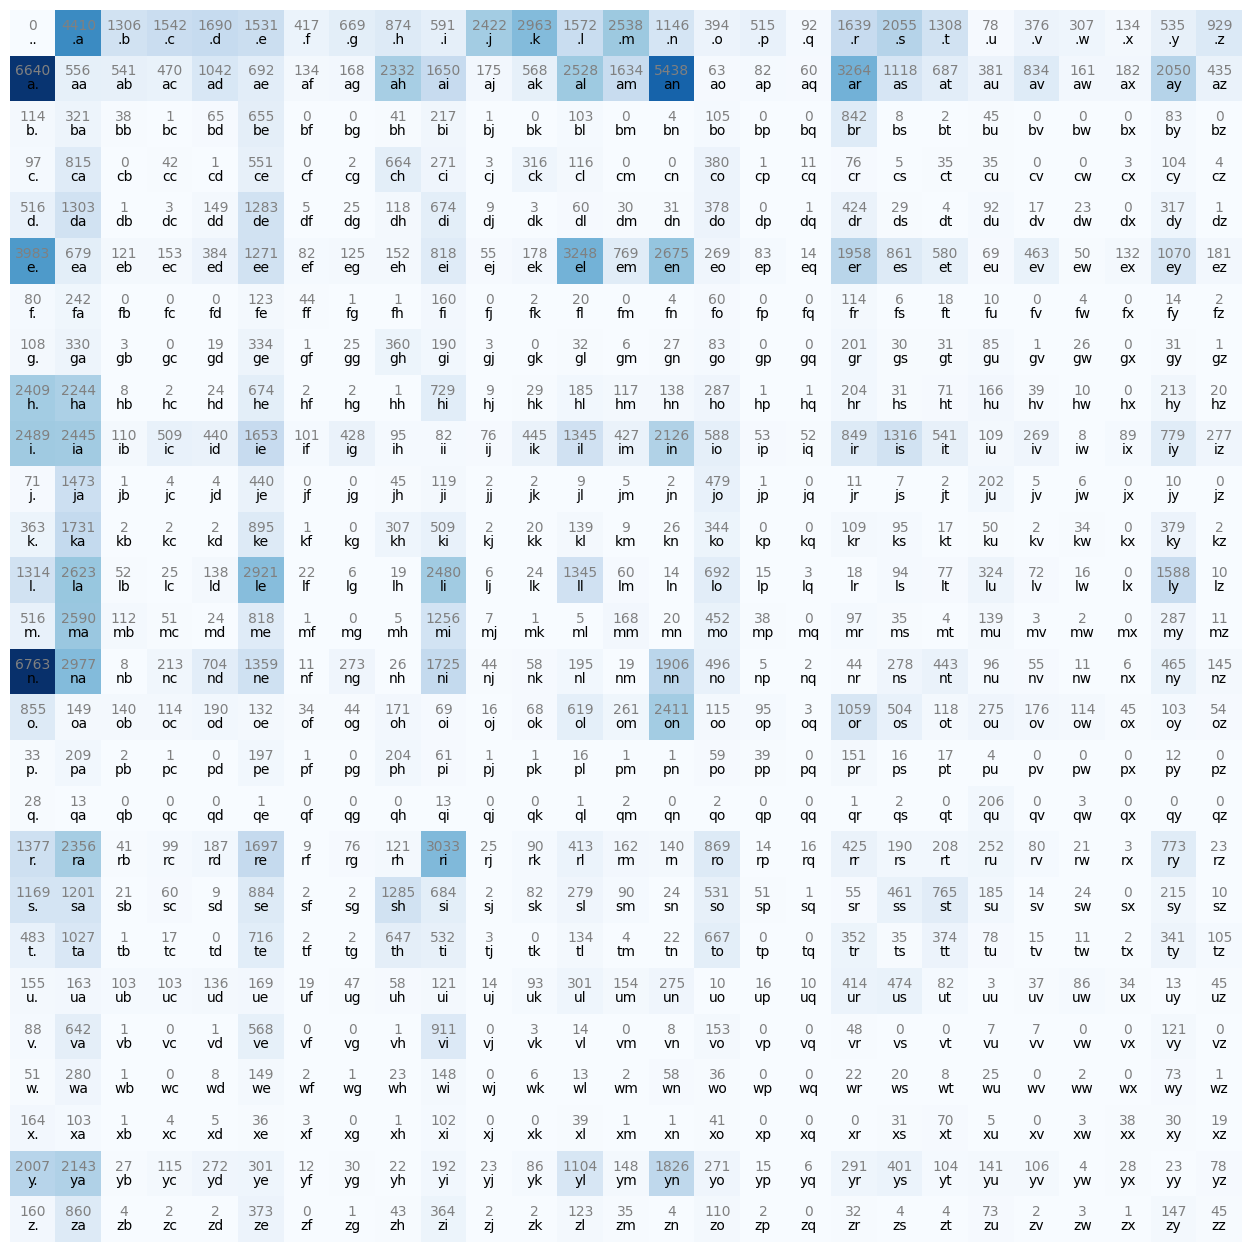

In [80]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 16))
plt.imshow(arr, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr= itos[i]  + itos[j]
        # Display the count from the adjacency matrix and the character pair at each cell
        plt.text(j, i, arr[i, j].item(), ha='center', va='bottom', color='gray')
        plt.text(j, i, chstr, ha='center', va='top', color='black')
plt.axis('off')
'''
When you use plt.imshow(arr, cmap='Blues'), the matrix arr is displayed such that:

Rows (i) correspond to the vertical axis (y-axis).
Columns (j) correspond to the horizontal axis (x-axis).
Why plt.text(j, i, ...) Aligns with arr[i, j]
In the adjacency matrix arr[i, j]:

i is the row index (first character).
j is the column index (second character).
When placing text on the plot:

plt.text(j, i, ...) specifies the position (j, i) in terms of the plot's x and y coordinates.
This matches the matrix cell arr[i, j] because:
j corresponds to the column (horizontal position).
i corresponds to the row (vertical position).'''

In [81]:
# hehe=[[1,2],[3,4]]
# plt.imshow(hehe, cmap='Blues')
# for i in range(2):
#     for j in range(2):
#         plt.text(i, j, hehe[i][j], ha='center', va='center', color='black')
# # plt.colorbar()

In [82]:
arr[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [83]:
p=arr[0].float() / arr[0].sum()  # Normalize the first row
print(p,p.sum())

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290]) tensor(1.)


In [84]:
g=torch.Generator().manual_seed(2147483647)  # Set a random seed for reproducibility
pp=torch.rand(3,generator=g)  # Generate 3 random numbers but sincw the generator is seeded, they will be the same every time
print(pp)

tensor([0.7081, 0.3542, 0.1054])


In [85]:
# we expect tensor([0.7081, 0.3542, 0.1054]) index 0 to come more and 2 thee leas which we can see now 
torch.multinomial(pp, num_samples=20, replacement=True, generator=g)  # Sample 20 indices based on the probabilities in p

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

In [86]:
ix=torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()  # Sample 1 indices based on the probabilities in p
sampled_char = itos[ix]  # Convert the sampled index to a character
print(sampled_char)  # Print the sampled character

h


In [110]:
P=arr.float()+1

In [111]:
P.sum(1,keepdim=True).shape

torch.Size([27, 1])

## Broadcasting

In [112]:
##broadcasting
# 27,27
# 27,1  it copies 27,1 27 times and then element wise divides

# if we didn't use keepdim=True, the shape would be (27,) and it would 
# 27,27
#    27  will broadcasted to 27,27 which is not what we want
P=P/ P.sum(1, keepdim=True)  # Normalize each row of the adjacency matrix

In [113]:
P[0].sum()  # Check if the first row sums to 1

tensor(1.)

### random generation based on the probabilites of bigram

In [114]:
g=torch.Generator().manual_seed(2147483647)  # Set a random seed for reproducibility
for i in range(20):
    ix=0
    out=[]
    while True:
        p=P[ix]  # Normalize the row
        ix=torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()  # Sample 1 index based on the probabilities in p
        if ix == 0:  # If the sampled index is 0 (the padding character), break the loop
            break
        sampled_char = itos[ix]  # Convert the sampled index to a character
        out.append(sampled_char) # Print the sampled character without a newline
    print(''.join(out))  # Join the sampled characters into a string and print it


cexze
momasurailezitynn
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda
ka
emimmsade
enkaviyny
ftlspihinivenvorhlasu
dsor
br
jol
pen
aisan
ja


In [115]:
log_likelihood = 0.0
n=0
for w in names:
    chs= ['.'] + list(w) + ['.']  # Add padding characters at the beginning and end
    for ch1, ch2 in zip(chs, chs[1:]):
        id1 = stoi[ch1]
        id2 = stoi[ch2]
        prob=P[id1, id2]
        logprob = torch.log(prob)  # Calculate the logarithm of the probability
        log_likelihood+=logprob
        n+=1
        # print(f"{ch1} -> {ch2}: {prob:.4f},{logprob:.4f}")  # Print the characters, probability, and log probability

# more negative log likelihood means less likely i.e less preferred 
print(f"Total log likelihood: {log_likelihood:.4f}")  # Print the total log likelihood
# we want to maximize the log likelihood and therefore minimize the negative log likelihood
# Negative log likelihood is often used as a loss function in machine learning, especially in classification tasks.
nll=-log_likelihood
print(f"Negative log likelihood: {nll:.4f}")  # Print the negative log likelihood
print(f"Average negative log likelihood: {nll/n:.4f}")  # Print the average negative log likelihood per character transition


Total log likelihood: -559951.5625
Negative log likelihood: 559951.5625
Average negative log likelihood: 2.4544


# Goal
### Maximize the likelihood of data wrt model parameters (statistical modelling)
### equivalent to maximizing the log likelihood and minimized nll/loss

In [ ]:
log_likelihood = 0.0
n=0
for w in ["harshitq"]:
    chs= ['.'] + list(w) + ['.']  # Add padding characters at the beginning and end
    for ch1, ch2 in zip(chs, chs[1:]):
        id1 = stoi[ch1]
        id2 = stoi[ch2]
        prob=P[id1, id2]
        logprob = torch.log(prob)  # Calculate the logarithm of the probability
        log_likelihood+=logprob
        n+=1
        # print(f"{ch1} -> {ch2}: {prob:.4f},{logprob:.4f}")  # Print the characters, probability, and log probability

# more negative log likelihood means less likely i.e less preferred 
print(f"Total log likelihood: {log_likelihood:.4f}")  # Print the total log likelihood
# we want to maximize the log likelihood and therefore minimize the negative log likelihood
# Negative log likelihood is often used as a loss function in machine learning, especially in classification tasks.
nll=-log_likelihood
print(f"Negative log likelihood: {nll:.4f}")  # Print the negative log likelihood
print(f"Average negative log likelihood: {nll/n:.4f}")  # Print the average negative log likelihood per character transition
# Model smoothing
# i am getting inf because there is no instance of 'q' followed by '.' in the names dataset, so the probability is 0, and log(0) is undefined (inf).
# To handle this, we can add a small constant (epsilon) to the probabilities to avoid taking the log of zero. so while calculating the probability matrix we add 1 to our count array 


Total log likelihood: -30.0096
Negative log likelihood: 30.0096
Average negative log likelihood: 3.3344


## creating a neural network model to predict the next character 

In [120]:
#training set
xs,ys=[],[]
for w in names[:1]:
    chs= ['.'] + list(w) + ['.']  # Add padding characters at the beginning and end
    for ch1, ch2 in zip(chs, chs[1:]):
        id1 = stoi[ch1]
        id2 = stoi[ch2]
        print(f"{ch1} -> {ch2}: {id1},{id2}")
        xs.append(id1)  # Append the index of the first character
        ys.append(id2)  # Append the index of the second character
xs=torch.tensor(xs)  # Convert the list of indices to a tensor
ys=torch.tensor(ys)  # Convert the list of indices to a tensor
print(xs.shape, ys.shape)  # Print the shapes of the input and output tensors

. -> e: 0,5
e -> m: 5,13
m -> m: 13,13
m -> a: 13,1
a -> .: 1,0
torch.Size([5]) torch.Size([5])


In [121]:
xs

tensor([ 0,  5, 13, 13,  1])

In [122]:
ys

tensor([ 5, 13, 13,  1,  0])

In [126]:
## we need to create each row of the input tensor as a one-hot encoded vector
import torch.nn.functional as F
xenc=F.one_hot(xs, num_classes=sz).float()  # Create a one-hot encoded tensor of the input indices
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

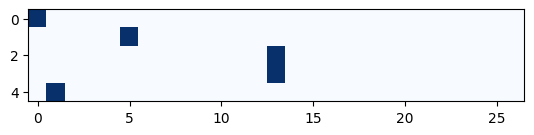

In [127]:
plt.imshow(xenc, cmap='Blues')  # Visualize the one-hot encoded tensor

In [130]:
W=torch.randn(sz, 1)  # Initialize a weight matrix with random values
xenc@W   #(5,27) @ (27,1) -> (5,1)  # Matrix multiplication to get the output logits

tensor([[-1.2780],
        [-0.5071],
        [ 0.9500],
        [ 0.9500],
        [-0.9577]])

In [ ]:
W=torch.randn((sz, sz),generator=g)  # Initialize a weight matrix with random values each column vector represents the weights of that neuron
logits=xenc@W   #(5,27) @ (27,27) -> (5,27)  # Matrix multiplication to get the output logits
# these are the log counts of the characters in the names dataset
# softmax
counts=logits.exp()  # Convert the logits to counts by taking the exponential just like aur arr of counts
prob= counts/counts.sum(1, keepdim=True)  # Normalize the counts to get probabilities
prob


tensor([[0.0298, 0.0967, 0.0072, 0.0186, 0.0442, 0.0087, 0.0456, 0.0032, 0.0243,
         0.0425, 0.0268, 0.0171, 0.0157, 0.0050, 0.1227, 0.0926, 0.0670, 0.0050,
         0.0131, 0.0353, 0.0373, 0.0585, 0.0594, 0.0217, 0.0288, 0.0557, 0.0174],
        [0.0119, 0.1048, 0.0051, 0.0136, 0.0094, 0.0403, 0.0688, 0.0391, 0.0094,
         0.0183, 0.0590, 0.0526, 0.0688, 0.0359, 0.0226, 0.0614, 0.0023, 0.0754,
         0.0664, 0.0556, 0.0047, 0.0195, 0.0213, 0.0234, 0.0047, 0.0546, 0.0512],
        [0.0485, 0.0077, 0.0446, 0.0181, 0.0353, 0.0081, 0.0147, 0.0289, 0.0986,
         0.0114, 0.0121, 0.0122, 0.0249, 0.0230, 0.0372, 0.0171, 0.0121, 0.0243,
         0.0120, 0.0364, 0.0448, 0.0067, 0.1158, 0.0198, 0.0308, 0.0783, 0.1765],
        [0.0485, 0.0077, 0.0446, 0.0181, 0.0353, 0.0081, 0.0147, 0.0289, 0.0986,
         0.0114, 0.0121, 0.0122, 0.0249, 0.0230, 0.0372, 0.0171, 0.0121, 0.0243,
         0.0120, 0.0364, 0.0448, 0.0067, 0.1158, 0.0198, 0.0308, 0.0783, 0.1765],
        [0.0242, 0.0125,

In [134]:
prob[0] # Print the probabilities for the first input character that was '.'

tensor([0.0434, 0.0494, 0.0117, 0.0133, 0.0742, 0.1137, 0.0310, 0.0212, 0.0425,
        0.0631, 0.0155, 0.0356, 0.0110, 0.0110, 0.0075, 0.0625, 0.0117, 0.0406,
        0.0174, 0.0604, 0.0304, 0.1270, 0.0103, 0.0189, 0.0382, 0.0338, 0.0044])

In [135]:
prob[0].shape # each of 27 is the probability of the next character given the first character is '.'

torch.Size([27])

In [140]:
nlls =torch.zeros(5)  # Initialize a tensor to store the negative log likelihoods
for i in range(5):
    x=xs[i] #input character index
    y=ys[i] #output character index
    print('--'*20)
    print(f'bigram example {i+1}: {itos[x.item()]} -> {itos[y.item()]} (indexes {x.item()}, {y.item()})')
    print('input to the neural network:', x)  
    print('output probabilities of the neural network:', prob[i])  # Print the probabilities for the i-th input character
    print('label(actual next character):', y)  # Print the label (next character index)
    p=prob[i,y]
    print('probability assigned by the nn to the correct character:', p.item())  # Print the probability assigned to the correct character
    logp=torch.log(p)  # Calculate the log probability
    nlls[i]=-logp  # Store the negative log likelihood
    print('negative log likelihood for this example:', nlls[i].item())  # Print the negative log likelihood for this example

print('=-'*20)
print('negative log likelihoods for all examples:', nlls)  # Print the negative log likelihoods for all examples
print('average negative log likelihood:', nlls.mean().item())  # Print the average negative log likelihood across all examples
    

----------------------------------------
bigram example 1: . -> e (indexes 0, 5)
input to the neural network: tensor(0)
output probabilities of the neural network: tensor([0.0298, 0.0967, 0.0072, 0.0186, 0.0442, 0.0087, 0.0456, 0.0032, 0.0243,
        0.0425, 0.0268, 0.0171, 0.0157, 0.0050, 0.1227, 0.0926, 0.0670, 0.0050,
        0.0131, 0.0353, 0.0373, 0.0585, 0.0594, 0.0217, 0.0288, 0.0557, 0.0174])
label(actual next character): tensor(5)
probability assigned by the nn to the correct character: 0.008719410747289658
negative log likelihood for this example: 4.742203712463379
----------------------------------------
bigram example 2: e -> m (indexes 5, 13)
input to the neural network: tensor(5)
output probabilities of the neural network: tensor([0.0119, 0.1048, 0.0051, 0.0136, 0.0094, 0.0403, 0.0688, 0.0391, 0.0094,
        0.0183, 0.0590, 0.0526, 0.0688, 0.0359, 0.0226, 0.0614, 0.0023, 0.0754,
        0.0664, 0.0556, 0.0047, 0.0195, 0.0213, 0.0234, 0.0047, 0.0546, 0.0512])
label(actua

## Final

In [141]:
## Backpropagation
import torch.optim as optim

In [175]:
#training set
xs,ys=[],[]
for w in names:
    chs= ['.'] + list(w) + ['.']  # Add padding characters at the beginning and end
    for ch1, ch2 in zip(chs, chs[1:]):
        id1 = stoi[ch1]
        id2 = stoi[ch2]
        # print(f"{ch1} -> {ch2}: {id1},{id2}")
        xs.append(id1)  # Append the index of the first character
        ys.append(id2)  # Append the index of the second character
xs=torch.tensor(xs)  # Convert the list of indices to a tensor
ys=torch.tensor(ys)  # Convert the list of indices to a tensor
print(xs.shape, ys.shape)  # Print the shapes of the input and output tensors

torch.Size([228146]) torch.Size([228146])


In [176]:
xs

tensor([ 0,  5, 13,  ..., 25, 26, 24])

In [177]:
ys.shape

torch.Size([228146])

In [178]:
g=torch.Generator().manual_seed(2147483647)  # Set a random seed for reproducibility
W=torch.randn((sz, sz), generator=g,requires_grad=True)  # Initialize a weight matrix with random values and enable gradient computation

In [179]:
xenc=F.one_hot(xs, num_classes=sz).float()  # Create a one-hot encoded tensor of the input indices
logits=xenc@W  # Matrix multiplication to get the output logits
counts=logits.exp()  # Convert the logits to counts by taking the exponential
prob= counts/counts.sum(1, keepdim=True)  # Normalize the counts to get probabilities
# prob[0,5] , prob[1,13],prob[2,13],prob[3,1],prob[4,0]  # Print the probabilities for specific character transitions
loss=-prob[torch.arange(len(xs)), ys].log().mean()  # Get the probabilities for the actual next character

In [180]:
#backward pass
W.grad = None  # Reset the gradient to None before backward pass
loss.backward()  # Perform backpropagation to compute gradients

In [181]:
W.grad

tensor([[ 8.5187e-03, -1.7928e-02, -3.9954e-03, -6.1678e-03, -5.0425e-03,
         -4.9856e-03, -1.4495e-03,  3.2138e-04, -1.9076e-03,  1.8004e-03,
         -9.5068e-03, -9.0844e-03, -5.6108e-03, -9.9720e-03,  1.9904e-03,
          3.1664e-02,  6.2140e-03, -5.3713e-05, -3.6864e-03, -8.2406e-03,
         -9.7537e-04,  1.1901e-03, -1.2434e-03,  1.4365e-03,  1.0683e-03,
          1.9233e-02,  1.6413e-02],
        [-2.6880e-02, -1.1534e-03,  3.5157e-03, -5.7258e-04,  4.4327e-03,
          1.5423e-03,  1.5517e-02,  1.2128e-03, -8.3641e-03, -6.5184e-03,
          1.4442e-02, -1.2133e-03,  3.5937e-03, -5.5054e-03, -2.0389e-02,
          2.7948e-03,  5.7026e-03,  8.9113e-04, -9.4967e-04,  2.9929e-03,
          3.8649e-03,  2.9188e-03, -2.8925e-03,  4.1746e-03,  8.9087e-03,
         -1.5171e-03, -5.5008e-04],
        [-2.1135e-04, -1.3155e-03,  1.9726e-04,  3.9496e-04, -1.8479e-04,
         -2.7573e-03,  2.8475e-04,  2.0133e-04, -9.1831e-05, -8.9764e-04,
          6.3084e-04,  1.0287e-04,  9.73

In [182]:
epochs=100
for epoch in range(epochs):
    logits=xenc@W
    counts=logits.exp()  # Convert the logits to counts by taking the exponential
    prob= counts/counts.sum(1, keepdim=True)  # Normalize the counts to get probabilities
    loss=-prob[torch.arange(len(xs)), ys].log().mean() +0.01*(W**2).mean() # Get the loss for the actual next character with regularization
    W.grad = None  # Reset the gradient to None before backward pass
    loss.backward()  # Perform backpropagation to compute gradients
    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')  # Print the loss for the current epoch
    with torch.no_grad():  # Disable gradient tracking for the weight update
        W -= 50 * W.grad  # Update the weights using gradient descent with a learning rate of 0.1
# After training, we can visualize the learned probabilities
counts=logits.exp()  # Convert the logits to counts by taking the exponential
prob= counts/counts.sum(1, keepdim=True)  # Normalize the counts to get probabilities
plt.figure(figsize=(16, 16))

Epoch 1/100, Loss: 3.7686
Epoch 2/100, Loss: 3.3788
Epoch 3/100, Loss: 3.1611


Epoch 4/100, Loss: 3.0272
Epoch 5/100, Loss: 2.9345
Epoch 6/100, Loss: 2.8672
Epoch 7/100, Loss: 2.8167
Epoch 8/100, Loss: 2.7771
Epoch 9/100, Loss: 2.7453
Epoch 10/100, Loss: 2.7188
Epoch 11/100, Loss: 2.6965
Epoch 12/100, Loss: 2.6774
Epoch 13/100, Loss: 2.6608
Epoch 14/100, Loss: 2.6464
Epoch 15/100, Loss: 2.6337
Epoch 16/100, Loss: 2.6225
Epoch 17/100, Loss: 2.6125
Epoch 18/100, Loss: 2.6037
Epoch 19/100, Loss: 2.5958
Epoch 20/100, Loss: 2.5887
Epoch 21/100, Loss: 2.5823
Epoch 22/100, Loss: 2.5764
Epoch 23/100, Loss: 2.5711
Epoch 24/100, Loss: 2.5663
Epoch 25/100, Loss: 2.5618
Epoch 26/100, Loss: 2.5577
Epoch 27/100, Loss: 2.5539
Epoch 28/100, Loss: 2.5504
Epoch 29/100, Loss: 2.5472
Epoch 30/100, Loss: 2.5442
Epoch 31/100, Loss: 2.5414
Epoch 32/100, Loss: 2.5387
Epoch 33/100, Loss: 2.5363
Epoch 34/100, Loss: 2.5340
Epoch 35/100, Loss: 2.5318
Epoch 36/100, Loss: 2.5298
Epoch 37/100, Loss: 2.5279
Epoch 38/100, Loss: 2.5261
Epoch 39/100, Loss: 2.5244
Epoch 40/100, Loss: 2.5228
Epoch 4

<Figure size 1600x1600 with 0 Axes>

<Figure size 1600x1600 with 0 Axes>

In [184]:
# sampling
g=torch.Generator().manual_seed(2147483647)  # Set a random seed for reproducibility
for i in range(5):
    ix=0
    out=[]
    while True:
        #before
        # p=P[ix]  # Normalize the row
        #now
        xenc=F.one_hot(torch.tensor([ix]), num_classes=sz).float()
        logits=xenc@W
        counts=logits.exp()
        p= counts/counts.sum(1, keepdim=True)
        ix=torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()  # Sample 1 index based on the probabilities in p
        if ix == 0:  # If the sampled index is 0 (the padding character), break the loop
            break
        sampled_char = itos[ix]  # Convert the sampled index to a character
        out.append(sampled_char) # Print the sampled character without a newline
    print(''.join(out))  # Join the sampled characters into a string and print it


cexze
momasurailezityha
konimittain
llayn
ka


In [185]:
## reached the same answer as before as the loss is almost same 